###**Section 3 : SQL Data analysis**

In this section, we will:

1. Load the cleaned dataset into a SQLite database for SQL querying
2. Analyze temporal consumption patterns (daily, hourly, seasonal)
3. Identify peak consumption events and outliers
4. Understand the contribution of each energy source to the production mix
5. Analyze energy exchanges with neighboring countries (imports/exports)


In [ ]:
#Link the colab to google drive to access the data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Import sqlite3 library
import sqlite3

#Import pandas library
import pandas as pd

#Import matplotlib library
import matplotlib.pyplot as plt

#Import seaborn library
import seaborn as sns

#Import plotly.express library
import plotly.express as px

#Read the cleaned dataset from the Data file
data_2022 = pd.read_csv("/content/drive/MyDrive/Capstone Project - Data & Energy/Project Energy System/Data/clean_data_2022.csv")

#Create a database file in sqlite
conn = sqlite3.connect("energy.db")

#Create a table energy in the energy.db file and fill it with the cleaned dataset
data_2022.to_sql("energy", conn, if_exists="replace")

17520

In [ ]:
#Verify the table structure
pd.read_sql("PRAGMA table_info(energy);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,index,INTEGER,0,None,0
1,1,timestamp,TEXT,0,None,0
2,2,Consommation,REAL,0,None,0
3,3,Prévision J-1,REAL,0,None,0
4,4,Prévision J,REAL,0,None,0
5,5,Fioul,REAL,0,None,0
6,6,Charbon,REAL,0,None,0
7,7,Gaz,REAL,0,None,0
8,8,Nucléaire,REAL,0,None,0
9,9,Eolien,REAL,0,None,0


**1. Temporal consumption patterns (Global system behavior)**

Analyze how energy consumption varies over time.

In [ ]:
# 1 - Identify the days that have the higher average consumption and order them from higher to lower
pd.read_sql("SELECT Date(Timestamp) AS Day, AVG(Consommation) AS Avg_consumption FROM energy GROUP BY Date(Timestamp) ORDER BY AVG(Consommation) DESC;", conn)

,Day,Avg_consumption
0,2022-01-26,78406.166667
1,2022-01-25,77810.083333
2,2022-01-27,77550.479167
3,2022-01-14,77323.416667
4,2022-01-13,76449.354167
...,...,...
360,2022-09-18,37914.541667
361,2022-08-15,37703.604167
362,2022-10-30,37475.916667
363,2022-08-14,37264.833333


**1 - Analysis #1**

These preliminary results show that the demand is higher during the winter months.

In [ ]:
# 2 - Identify the times per day that have the higher average consumption and order them from higher to lower
pd.read_sql("SELECT TIME(Timestamp), AVG(Consommation) FROM energy GROUP BY TIME(Timestamp) ORDER BY AVG(Consommation) DESC;", conn)

,TIME(Timestamp),AVG(Consommation)
0,12:30:00,57096.043836
1,13:00:00,56999.706849
2,12:00:00,56818.438356
3,11:30:00,56182.046575
4,11:00:00,55885.747945
5,19:30:00,55840.953425
6,13:30:00,55780.789041
7,10:30:00,55692.484932
8,19:00:00,55607.000000
9,10:00:00,55502.860274


**1 - Analysis #2**

The results show that the demand is higher during lunch hours (roughly 12h to 14h) and in the evenings (from 18h to 21h).

This analysis remains very limited though because it ignores the seasonality and the meteo conditions.
That's why we are going to conduct the analysis by season.

<Axes: xlabel='Time', ylabel='Season'>

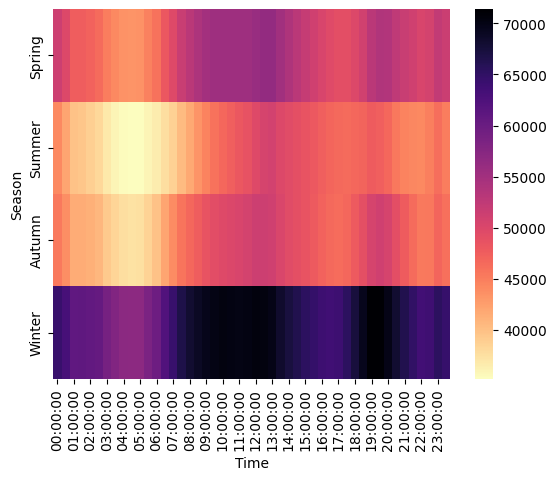

In [ ]:
# 2.1 - Fetch the times per day that have the higher average consumption and order them from higher to lower
df = pd.read_sql("""SELECT TIME(Timestamp) AS Time,
                    AVG(Consommation) AS Avg_consumption,
                    Season
                FROM (
                  SELECT (Timestamp), Consommation,
                    strftime('%m', Timestamp),
                  CASE WHEN strftime('%m', Timestamp) IN ('12','01','02') THEN 'Winter'
                  WHEN strftime('%m', Timestamp) IN ('03','04','05') THEN 'Spring'
                  WHEN strftime('%m', Timestamp) IN ('06','07','08') THEN 'Summer'
                  WHEN strftime('%m', Timestamp) IN ('09','10','11') THEN 'Autumn'
                  END AS Season  FROM energy
                )
                GROUP BY Time, Season
                ORDER BY AVG(Consommation) DESC;""",
                 conn)

#Pivot the table

df = df.pivot_table(index ='Season', values = 'Avg_consumption', columns ='Time', aggfunc = 'mean')
df = df.reindex(['Spring', 'Summer', 'Autumn', 'Winter'])
df
#Create the heatmap
sns.heatmap(df, cmap = 'magma_r')


**1 - Analysis #3**

Regarding seasonal patterns, the heatmap shows that:
- Winter exhibits the highest energy consumption, mainly due to increased heating demand.
- Summer has the lowest consumption levels, reflecting reduced energy needs.
- Autumn and Spring show moderate consumption levels, with slightly higher values observed in Spring.

Regarding daily patterns:
- Energy consumption tends to increase in the morning (from 7:00 to 13:00) and in the evening (from 18:00 to 21:00) across all seasons.
- Lower consumption levels are observed during nighttime hours, indicating reduced activity.

**2. Peak consumption analysis (System stress)**

Identify critical moments of high energy demand.

In [ ]:
pd.read_sql("""SELECT Timestamp AS Time, Consommation FROM energy
ORDER BY Consommation DESC LIMIT 10 ;""", conn)

,Time,Consommation
0,2022-01-14 09:30:00,86991.0
1,2022-01-14 10:00:00,86528.0
2,2022-01-14 09:00:00,86496.0
3,2022-01-14 08:30:00,86241.0
4,2022-01-14 10:30:00,85880.0
5,2022-01-26 12:00:00,85837.0
6,2022-01-26 12:30:00,85760.0
7,2022-01-25 09:00:00,85736.0
8,2022-01-26 10:30:00,85604.0
9,2022-01-26 10:00:00,85488.0


**2 - Analysis #1**

The top 10 highest consumption values are all observed in January and occur mainly during the morning hours.

Interestingly, while average consumption tends to peak in the evening, the highest extreme values are recorded in the morning. This suggests that peak demand is not only driven by residential usage, but also by industrial and economic activity that typically takes place earlier in the day.

In [ ]:
#Calculate the mean and the standard deviation of the Consommation column of the data_2022
std = data_2022["Consommation"].std()
mean = data_2022["Consommation"].mean()

#Calculate the threshold
threshold = mean + 3*std

# Print the the mean, the standard deviation and the threshold
print ("The mean is ", mean)
print ("The standard deviation is", std)
print ("The threshold is", threshold)


The mean is  51482.572488584476
The standard deviation is 11388.971963941845
The threshold is 85649.48838041001


In [ ]:
#Identify the outliers (days where the consumption has been higher than the threshold)

outliers = data_2022[data_2022["Consommation"]>threshold]
outliers

,timestamp,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,Nucléaire,Eolien,Solaire,...,Hydraulique - Fil de l’eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies- Déchets,BioénergiesBiomasse,Bioénergies- Biogaz,Stockage batterie,Déstockage batteries,Eolien terrestre,Eolien offshore
641,2022-01-14 08:30:00,86241.0,84500.0,86500.0,389.0,1720.0,8975.0,48450.0,845.0,25.0,...,6851.0,4937.0,4066.0,508.0,326.0,329.0,0.0,0.0,844.0,0.0
642,2022-01-14 09:00:00,86496.0,84700.0,86500.0,406.0,1714.0,8813.0,48581.0,834.0,357.0,...,7087.0,4984.0,3926.0,508.0,337.0,329.0,0.0,0.0,833.0,0.0
643,2022-01-14 09:30:00,86991.0,84600.0,86700.0,410.0,1716.0,9034.0,48582.0,834.0,1168.0,...,7158.0,5845.0,4022.0,504.0,344.0,330.0,0.0,0.0,833.0,0.0
644,2022-01-14 10:00:00,86528.0,84000.0,85800.0,404.0,1635.0,8817.0,48530.0,867.0,2228.0,...,7210.0,5241.0,3620.0,505.0,346.0,335.0,0.0,0.0,867.0,0.0
645,2022-01-14 10:30:00,85880.0,83300.0,85000.0,406.0,1650.0,9092.0,48550.0,780.0,3296.0,...,7226.0,5042.0,2459.0,507.0,342.0,339.0,0.0,0.0,779.0,0.0
1170,2022-01-25 09:00:00,85736.0,85600.0,85300.0,1458.0,1767.0,8993.0,48919.0,312.0,445.0,...,5840.0,6837.0,4125.0,476.0,336.0,325.0,0.0,0.0,311.0,0.0
1224,2022-01-26 12:00:00,85837.0,84200.0,84900.0,604.0,1663.0,8058.0,49256.0,576.0,4884.0,...,5396.0,4648.0,1184.0,527.0,316.0,326.0,0.0,0.0,576.0,0.0
1225,2022-01-26 12:30:00,85760.0,83300.0,84300.0,609.0,1657.0,8065.0,49276.0,584.0,5167.0,...,5276.0,4064.0,1110.0,522.0,317.0,330.0,0.0,0.0,584.0,0.0


**2 - Analysis #2**

- The outliers are concentrated in January, which corresponds to winter and higher electricity demand due to heating needs.

- The day-ahead forecasts (“Prévision J”) are very close to actual consumption, indicating accurate demand prediction.

- Nuclear energy represents the largest share of electricity generation, confirming its role as the main base load source in France.

- However, the outliers are relatively rare, with only 8 extreme peaks identified over the year.

**3. Energy source contribution**

Understand the role of different energy sources in total production.


In [ ]:
#Identify the average power generation by source
Sources = pd.read_sql("""SELECT AVG(Fioul), AVG(Charbon), AVG(Gaz), AVG(Nucléaire), AVG(Eolien), AVG(Solaire), AVG(Hydraulique), AVG(Pompage), AVG(Bioénergies) FROM energy;""", conn)

# Transpose the DataFrame to have energy sources as index and their average values as a column
Sources = Sources.T
Sources.columns = ['Average']
Sources.index.names = ['Source']
Sources.sort_values(by= 'Average', ascending = False)

,Average
Source,
AVG(Nucléaire),31827.007420
AVG(Hydraulique),5611.219635
AVG(Gaz),5008.483505
AVG(Eolien),4438.363870
AVG(Solaire),2159.226941
AVG(Bioénergies),1206.194463
AVG(Charbon),327.471975
AVG(Fioul),129.688984
AVG(Pompage),-849.471233


**3 - Analysis #1**

Nuclear energy clearly dominates total production, indicating its role as the primary base-load energy source. This suggests that it provides a stable and continuous supply of electricity.

Hydropower, gaz and wind energy contribute moderately to the overall production, acting as complementary sources. However, their contribution remains significantly lower than nuclear.

It is important to note that pumped storage (*Pompage* = STEP: Stations de Transfert d’Énergie par Pompage ) is not an energy production source, but rather a storage mechanism. The negative average value indicates that energy is consumed to store electricity, which can later be released during peak demand periods.
*(See image below)*

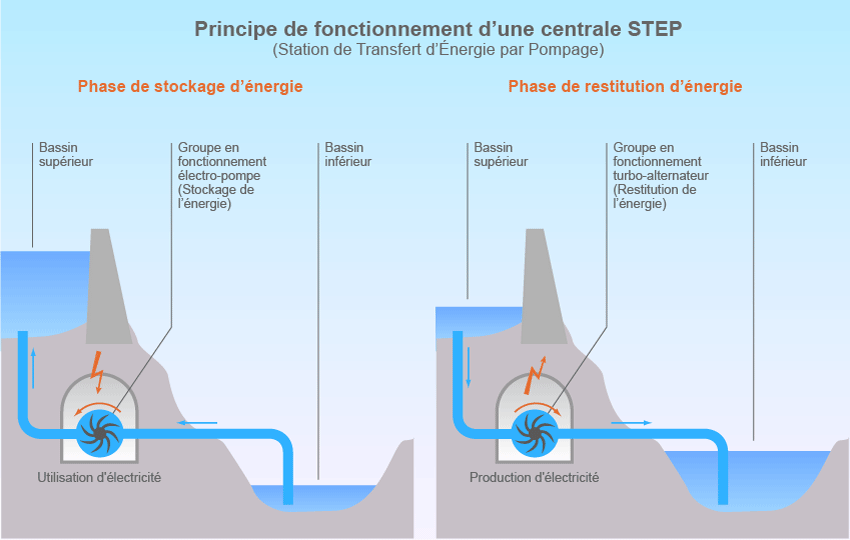

Source: https://www.encyclopedie-energie.org/les-stations-de-pompage-step/


In [ ]:
#Display the image frome Drive

from IPython.display import Image, display
display(Image(filename='/content/drive/MyDrive/Capstone Project - Data & Energy/Project Energy System/Images/centrale-step-2_zoom_0.png'))

print ('Source: https://www.encyclopedie-energie.org/les-stations-de-pompage-step/')

In [ ]:
#Identify the sources power generation variation across seasons
Sources_variation = pd.read_sql("""SELECT AVG(Fioul), AVG(Charbon), AVG(Gaz), AVG(Nucléaire), AVG(Eolien), AVG(Solaire), AVG(Hydraulique), AVG(Pompage), AVG(Bioénergies), Season
FROM (
  SELECT Fioul,Charbon,Gaz, Nucléaire, Eolien, Solaire,Hydraulique,Pompage, Bioénergies,
   strftime('%m', Timestamp),
  CASE WHEN strftime('%m', Timestamp) IN ('12', '01','02') THEN 'winter'
   WHEN strftime('%m', Timestamp)  IN ('03', '04','05') THEN 'spring'
   WHEN strftime('%m', Timestamp)  IN ('06', '07','08') THEN 'summer'
   WHEN strftime('%m', Timestamp)  IN ('09', '10','11') THEN 'autumn'
  END AS Season FROM energy)
  GROUP BY Season;""", conn)

Sources_variation = Sources_variation.set_index('Season')
Sources_variation

,AVG(Fioul),AVG(Charbon),AVG(Gaz),AVG(Nucléaire),AVG(Eolien),AVG(Solaire),AVG(Hydraulique),AVG(Pompage),AVG(Bioénergies)
Season,,,,,,,,,
autumn,88.032509,122.906364,5113.872253,27443.725275,4910.032967,1803.685897,4259.603480,-982.736264,1177.143086
spring,129.501132,239.617074,4836.375679,31315.659647,4187.017889,2499.154891,6562.590580,-759.547781,1248.564538
summer,136.870924,26.600543,3664.569293,25837.837636,2630.597373,3257.778759,4580.098505,-662.274457,1173.926404
winter,164.658796,931.675231,6451.635185,42903.966204,6066.324537,1048.272454,7059.376157,-998.003935,1225.242130


In [ ]:
#Generate a grouped bar chart : sources contribution vs seasons
fig = px.bar(Sources_variation, x= Sources_variation.index, y=['AVG(Fioul)',	'AVG(Charbon)','AVG(Gaz)', 'AVG(Nucléaire)','AVG(Eolien)', 'AVG(Solaire)', 'AVG(Hydraulique)', 'AVG(Pompage)', 'AVG(Bioénergies)'],
             labels= {"value" : "Power generation"},
             title = "Energy production by source and season")

fig.show()

**3 - Analysis #2**

Overall, the contribution of energy sources remains relatively proportional across seasons, following the variation in total electricity demand. Nuclear energy consistently represents the largest share of electricity production in all seasons.

Coal (“Charbon”) production appears mainly during winter and spring, which may indicate its use as a supplementary source to support periods of higher electricity demand.

Wind and solar production are variable due to weather conditions.

**4. Energy exchanges (Imports / Exports)**

Analyze electricity exchanges with neighboring countries.


**DISCLAIMER**


In this section, we are going to focus on column "Ech. physiques" which represents **the physical exchanges**, i.e. the actual electricity flows crossing borders and the overall international exchange balance.

However, to define the principal partner countries, we are using columns "Ech. comm. Angleterre", "Ech. comm. Espagne", "Ech. comm. Italie", "Ech. comm. Suisse", "Ech. comm. Allemagne-Belgique", which represent **commercial exchanges**, i.e. the electricity traded between countries based on market or contractual agreements in the interconnected European network.

In [ ]:
# Determine the net sum of the "Ech. physiques" column
net_sum_exchange = data_2022["Ech. physiques"].sum()

if net_sum_exchange > 0:
    print("Net importer of electricity by", net_sum_exchange, "MW")
else:
    print("Net exporter of electricity", net_sum_exchange, "MW")

Net importer of electricity by 29681752.0 MW


**4 - Analysis #1**

- The results show that France has been a net importer of electricity during the year 2022.

**P.S.**
- **(Ech physique > 0 ) = imports**
- **(Ech physique < 0 ) = exports**

In [ ]:
# Identify the main energy exchange partners by calculating the total exchange volume per country
# ABS() is used to measure the overall volume of exchanges, regardless of direction (imports or exports)
# The percentage represents each country's share of France's total exchange volume

Main_partners = pd.read_sql("""
SELECT "England" AS Country,
ABS(SUM("Ech. comm. Angleterre")) AS Total_exchange,
((ABS(SUM("Ech. comm. Angleterre")))/((ABS(SUM("Ech. comm. Angleterre"))) + (ABS(SUM("Ech. comm. Espagne"))) + (ABS(SUM("Ech. comm. Italie")))+(ABS(SUM("Ech. comm. Suisse")))+(ABS(SUM("Ech. comm. Allemagne-Belgique")))))*100 AS Percentage FROM energy

UNION ALL

SELECT "Spain" AS Country,
ABS(SUM("Ech. comm. Espagne")) AS Total_exchange,
((ABS(SUM("Ech. comm. Espagne")))/((ABS(SUM("Ech. comm. Angleterre"))) + (ABS(SUM("Ech. comm. Espagne"))) + (ABS(SUM("Ech. comm. Italie")))+(ABS(SUM("Ech. comm. Suisse")))+(ABS(SUM("Ech. comm. Allemagne-Belgique")))))*100 AS Percentage FROM energy

UNION ALL

SELECT "Italy" AS Country,
ABS(SUM("Ech. comm. Italie")) AS Total_exchange,
((ABS(SUM("Ech. comm. Italie")))/((ABS(SUM("Ech. comm. Angleterre"))) + (ABS(SUM("Ech. comm. Espagne"))) + (ABS(SUM("Ech. comm. Italie")))+(ABS(SUM("Ech. comm. Suisse")))+(ABS(SUM("Ech. comm. Allemagne-Belgique")))))*100 AS Percentage FROM energy


UNION ALL

SELECT "Switzerland" AS Country,
ABS(SUM("Ech. comm. Suisse")) AS Total_exchange,
((ABS(SUM("Ech. comm. Suisse")))/((ABS(SUM("Ech. comm. Angleterre"))) +(ABS(SUM("Ech. comm. Espagne"))) + (ABS(SUM("Ech. comm. Italie")))+(ABS(SUM("Ech. comm. Suisse")))+(ABS(SUM("Ech. comm. Allemagne-Belgique")))))*100 AS Percentage FROM energy

UNION ALL

SELECT "Germany-Belgium" AS Country,
ABS(SUM("Ech. comm. Allemagne-Belgique")) AS Total_exchange,
((ABS(SUM("Ech. comm. Allemagne-Belgique")))/((ABS(SUM("Ech. comm. Angleterre"))) +(ABS(SUM("Ech. comm. Espagne"))) + (ABS(SUM("Ech. comm. Italie")))+(ABS(SUM("Ech. comm. Suisse")))+(ABS(SUM("Ech. comm. Allemagne-Belgique")))))*100 AS Percentage FROM energy

ORDER BY Total_exchange DESC;""",
                            conn)
Main_partners

,Country,Total_exchange,Percentage
0,Germany-Belgium,54901028.0,35.897079
1,Italy,35829000.0,23.426819
2,Switzerland,24150783.0,15.791008
3,England,19867426.0,12.990332
4,Spain,18191862.0,11.894763


Text(0.5, 1.0, 'Energy Exchange Partners of France')

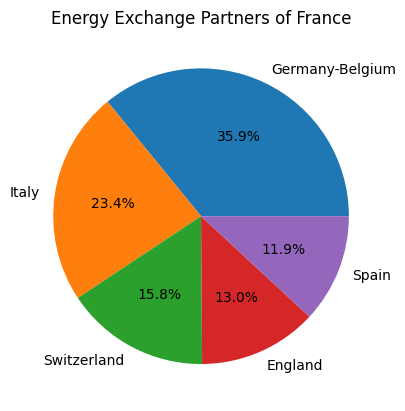

In [ ]:
# Generate a pie chart showing the share of each country in France's total energy exchange volume

plt.pie(Main_partners["Percentage"], labels = Main_partners["Country"],autopct='%1.1f%%')
plt.title("Energy Exchange Partners of France")

**4 - Analysis #2**

From the pie chart above, we can observe that Germany-Belgium represents France’s main energy exchange partner in terms of total electricity exchange volume.

The calculations were performed using absolute values in order to measure the overall volume of exchanges, independently from the direction of the flow (imports or exports).

The chart also highlights the importance of exchanges with Germany-Belgium and Italy, since they, together, account for more than half of the total exchange volume.


In [ ]:
#Define the energy exchanges with each country over the months

Exchange_variation = pd.read_sql("""SELECT SUM("Ech. comm. Angleterre"), SUM("Ech. comm. Espagne"),SUM("Ech. comm. Italie"), SUM("Ech. comm. Suisse"), SUM("Ech. comm. Allemagne-Belgique"),   strftime('%m', Timestamp) AS Month
FROM energy
  GROUP BY Month;""", conn)
Exchange_variation = Exchange_variation.set_index('Month')
Exchange_variation

,"SUM(""Ech. comm. Angleterre"")","SUM(""Ech. comm. Espagne"")","SUM(""Ech. comm. Italie"")","SUM(""Ech. comm. Suisse"")","SUM(""Ech. comm. Allemagne-Belgique"")"
Month,,,,,
01,-131388.0,881018.0,-1958076.0,-2653661.0,6244077.0
02,-459632.0,-1955750.0,-3473170.0,-3427573.0,5863690.0
03,158.0,536378.0,-2190874.0,-2356899.0,6407562.0
04,1237728.0,1621326.0,-2669200.0,-1096266.0,3362907.0
05,2367868.0,824386.0,-4182398.0,-1301002.0,1427810.0
06,3084678.0,543966.0,-2824882.0,-1526423.0,3181848.0
07,3635236.0,1979438.0,-3428072.0,-408206.0,5126483.0
08,2274556.0,2960352.0,-1608574.0,-834497.0,3933274.0
09,2968380.0,3572978.0,-3226018.0,-1415390.0,4917918.0


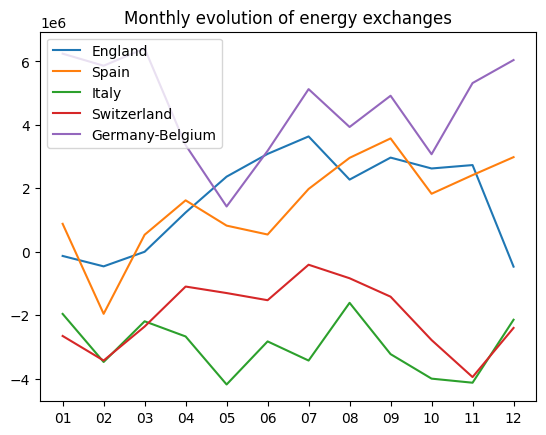

In [ ]:
# Generate a line chart showing the evolution of energy exchanges with each partner country over the months
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Exchange_variation.index, Exchange_variation['SUM("Ech. comm. Angleterre")'], label = "England")
ax.plot(Exchange_variation.index,Exchange_variation['SUM("Ech. comm. Espagne")'], label = "Spain")
ax.plot(Exchange_variation.index,Exchange_variation['SUM("Ech. comm. Italie")'], label = "Italy")
ax.plot(Exchange_variation.index,Exchange_variation['SUM("Ech. comm. Suisse")'], label = "Switzerland")
ax.plot(Exchange_variation.index,Exchange_variation['SUM("Ech. comm. Allemagne-Belgique")'],  label = "Germany-Belgium")
plt.title("Monthly evolution of energy exchanges")

ax.legend()

**4 - Analysis #3**

The overall pattern suggests that France's exchange dynamics are strongly influenced by seasonal demand, with higher import activity during winter months when consumption peaks.


In [ ]:
# Classify physical exchanges (import or export) during peak periods (= periods where consumption exceeds the yearly average)
peaks = pd.read_sql("""SELECT "Ech. physiques",
 CASE WHEN "Ech. physiques">0 THEN "Import"
  WHEN  "Ech. physiques"<0 THEN "Export" END AS Flow_type
  FROM energy
WHERE Consommation > (SELECT AVG(Consommation) FROM energy)
 ;""", conn)


peaks

,Ech. physiques,Flow_type
0,-2589.0,Export
1,-2769.0,Export
2,-2788.0,Export
3,-2749.0,Export
4,-1975.0,Export
...,...,...
7258,-3265.0,Export
7259,-2770.0,Export
7260,-1901.0,Export
7261,-2379.0,Export


**4 - Analysis #4**

 While we might expect that peak consumption periods would systematically drive higher imports, the table above shows that France maintained export activity even during high-demand moments in 2022.

In [ ]:
# Compare the average physical exchange volume between peak and non-peak consumption periods
peak_exchanges = pd.read_sql("""SELECT
CASE WHEN Consommation > (SELECT AVG(Consommation) FROM energy) THEN 'Peak'
ELSE 'Non-Peak'
END AS "Peak/Non-Peak",

AVG("Ech. physiques") AS Avg_exchange

FROM energy
GROUP BY "Peak/Non-Peak";
""", conn)
peak_exchanges

,Peak/Non-Peak,Avg_exchange
0,Non-Peak,1555.832310
1,Peak,1889.519482


In [ ]:
#Generate a  bar chart : peaks/non-peaks vs exchanges
fig = px.bar(peak_exchanges, x= chart_data["Peak/Non-Peak"], y=chart_data["Avg_exchange"],
             title = "Peaks VS energy exchange")

fig.show()

**4 - Analysis #5**

The bar chart confirms that France imported electricity during both peak and non-peak periods in 2022, with the average physical exchange being positive in both cases.
However, the average exchange volume is notably higher during peak periods, indicating that imports intensify when demand is elevated.

**5. Key findings**

- Temporal patterns: consumption is highest during winter and during morning/evening peaks. Seasonal analysis reveals that daily patterns are consistent across seasons, but winter demand levels are significantly higher.

- Peak events: extreme consumption events are rare (only 8 outliers) and concentrated in January mornings, driven by industrial activity rather than just residential demand. Forecasts accurately predicted these peaks.

- Energy mix: nuclear dominates the production mix across all seasons. Wind and solar show high variability, while nuclear remains relatively stable. Coal is used primarily as a winter supplement.

- Energy exchanges:
  - Germany-Belgium is the main exchange partner.
  - France was a net importer of electricity in 2022, a notable shift for a country historically powered by its nuclear fleet. This was largely driven by reduced nuclear availability: corrosion issues first detected at Civaux 1 in December 2021 forced extended outages, compounded by delayed maintenance from the Covid-19 pandemic and industrial action. Nuclear reactors require regular shutdowns for refueling (40 days every 12-18 months), partial safety inspections (3 months every 3-4 years), and decennial safety reviews, making availability highly variable year to year.
  
  *(Sources: world-nuclear.org, analysesetdonnees.rte-france.com)*